# Fitness Analysis Report

This notebook analyzes fitness results from directories 01-10 for both greedy and mcfp methods.
It extracts minimum fitness values and calculates statistics including average, median, and mode.

In [2]:
import os
import glob
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
def load_fitness_data(base_dir='.'):
    """
    Load fitness data from directories 01-10 for both greedy and mcfp methods.
    Returns a DataFrame with all fitness values and metadata.
    """
    data = []
    
    for dir_num in range(1, 11):
        dir_name = f"{dir_num:02d}"
        dir_path = os.path.join(base_dir, dir_name)
        
        if not os.path.exists(dir_path):
            print(f"Warning: Directory {dir_name} not found")
            continue
            
        # Find all fitness files in this directory
        fitness_files = glob.glob(os.path.join(dir_path, '*_F'))
        
        for fitness_file in fitness_files:
            # Extract metadata from filename
            filename = os.path.basename(fitness_file)
            parts = filename.split('_')
            
            if len(parts) >= 3:
                scenario = parts[0]
                problem = parts[1]
                method = parts[2]
                
                # Read fitness value
                try:
                    with open(fitness_file, 'r') as f:
                        fitness_line = f.readline().strip()
                        # Extract first number (fitness value)
                        fitness_value = float(fitness_line.split()[0])
                        
                    # Read result file for additional info
                    result_file = fitness_file.replace('_F', '_result.txt')
                    additional_info = {}
                    
                    if os.path.exists(result_file):
                        with open(result_file, 'r') as f:
                            lines = f.readlines()
                            for line in lines[:10]:  # Read first 10 lines for metadata
                                if 'Number of Points:' in line:
                                    additional_info['num_points'] = int(line.split(':')[1].strip())
                                elif 'Number of Clusters:' in line:
                                    additional_info['num_clusters'] = int(line.split(':')[1].strip())
                                elif 'Problem Dimensions:' in line:
                                    additional_info['dimensions'] = int(line.split(':')[1].strip())
                    
                    data.append({
                        'directory': dir_name,
                        'scenario': scenario,
                        'problem': problem,
                        'method': method,
                        'fitness': fitness_value,
                        'filename': filename,
                        **additional_info
                    })
                    
                except (ValueError, FileNotFoundError, IndexError) as e:
                    print(f"Error processing {fitness_file}: {e}")
    
    return pd.DataFrame(data)

# Load all data
df = load_fitness_data()
print(f"Loaded {len(df)} records")
print(f"Methods found: {df['method'].unique()}")
print(f"Directories: {sorted(df['directory'].unique())}")
df.head()

Loaded 600 records
Methods found: ['mcfp' 'greedy']
Directories: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']


,directory,scenario,problem,method,fitness,filename,num_points,num_clusters,dimensions
0,01,s8,p8,mcfp,12881.1,s8_p8_mcfp_F,75,4,2
1,01,s17,p8,greedy,12881.1,s17_p8_greedy_F,75,4,2
2,01,s21,p8,greedy,12881.1,s21_p8_greedy_F,75,4,2
3,01,s19,p8,mcfp,12881.1,s19_p8_mcfp_F,75,4,2
4,01,s2,p8,greedy,12881.1,s2_p8_greedy_F,75,4,2


In [10]:
def get_minimum_fitness_per_directory(df):
    """
    For each directory and method, find the minimum fitness value and its information.
    """
    results = []
    
    for directory in sorted(df['directory'].unique()):
        dir_data = df[df['directory'] == directory]
        
        for method in ['greedy', 'mcfp']:
            method_data = dir_data[dir_data['method'] == method]
            
            if not method_data.empty:
                min_idx = method_data['fitness'].idxmin()
                min_record = method_data.loc[min_idx]
                
                results.append({
                    'directory': directory,
                    'method': method,
                    'min_fitness': min_record['fitness'],
                    'scenario': min_record['scenario'],
                    'problem': min_record['problem'],
                    'num_points': min_record.get('num_points', 'N/A'),
                    'num_clusters': min_record.get('num_clusters', 'N/A'),
                    'dimensions': min_record.get('dimensions', 'N/A'),
                    'filename': min_record['filename']
                })
    
    return pd.DataFrame(results)

min_fitness_df = get_minimum_fitness_per_directory(df)
print("\nMinimum fitness values per directory and method:")
min_fitness_df


Minimum fitness values per directory and method:


,directory,method,min_fitness,scenario,problem,num_points,num_clusters,dimensions,filename
0,01,greedy,1.288110e+04,s17,p8,75,4,2,s17_p8_greedy_F
1,01,mcfp,1.288110e+04,s8,p8,75,4,2,s8_p8_mcfp_F
2,02,greedy,2.993650e+10,s14,p54,106,6,9,s14_p54_greedy_F
3,02,mcfp,2.371140e+10,s4,p54,106,6,9,s4_p54_mcfp_F
4,03,greedy,7.577430e+06,s15,p7192,118,4,1798,s15_p7192_greedy_F
5,03,mcfp,7.699950e+06,s8,p7192,118,4,1798,s8_p7192_mcfp_F
6,04,greedy,8.136720e+01,s16,p12,150,3,4,s16_p12_greedy_F
7,04,mcfp,8.136720e+01,s28,p12,150,3,4,s28_p12_mcfp_F
8,05,greedy,9.304120e+06,s2,p5460,155,5,1092,s2_p5460_greedy_F
9,05,mcfp,9.287770e+06,s11,p5460,155,5,1092,s11_p5460_mcfp_F


In [12]:
def calculate_fitness_statistics_per_directory(df):
    """
    Calculate fitness statistics (average, median, mode) for each directory (dataset) and method.
    """
    stats_results = []
    
    for directory in sorted(df['directory'].unique()):
        dir_data = df[df['directory'] == directory]
        
        for method in ['greedy', 'mcfp']:
            method_data = dir_data[dir_data['method'] == method]['fitness']
            
            if not method_data.empty:
                # Calculate statistics
                avg_fitness = method_data.mean()
                median_fitness = method_data.median()
                
                # Calculate mode (most frequent value)
                mode_result = stats.mode(method_data, keepdims=True)
                mode_fitness = mode_result.mode[0] if len(mode_result.mode) > 0 else 'N/A'
                mode_count = mode_result.count[0] if len(mode_result.count) > 0 else 0
                
                # Additional statistics
                std_fitness = method_data.std()
                min_fitness = method_data.min()
                max_fitness = method_data.max()
                count = len(method_data)
                
                stats_results.append({
                    'directory': directory,
                    'method': method,
                    'count': count,
                    'average': avg_fitness,
                    'median': median_fitness,
                    'mode': mode_fitness,
                    'mode_frequency': mode_count,
                    'std_deviation': std_fitness,
                    'minimum': min_fitness,
                    'maximum': max_fitness
                })
    
    return pd.DataFrame(stats_results)

# Calculate statistics per directory
stats_per_dir_df = calculate_fitness_statistics_per_directory(df)
print("\nFitness Statistics per Directory and Method:")
print(stats_per_dir_df.round(4))


Fitness Statistics per Directory and Method:
   directory  method  count       average        median          mode  \
0         01  greedy     30  1.310984e+04  1.288110e+04  1.288110e+04   
1         01    mcfp     30  1.288110e+04  1.288110e+04  1.288110e+04   
2         02  greedy     30  3.068199e+10  3.072890e+10  3.072890e+10   
3         02    mcfp     30  2.371140e+10  2.371140e+10  2.371140e+10   
4         03  greedy     30  7.647687e+06  7.650775e+06  7.577430e+06   
5         03    mcfp     30  7.839029e+06  7.845160e+06  7.699950e+06   
6         04  greedy     30  8.170860e+01  8.167380e+01  8.136720e+01   
7         04    mcfp     30  8.136720e+01  8.136720e+01  8.136720e+01   
8         05  greedy     30  9.332947e+06  9.333485e+06  9.304120e+06   
9         05    mcfp     30  9.289684e+06  9.289800e+06  9.287770e+06   
10        06  greedy     30  4.439643e+09  4.433130e+09  3.966060e+09   
11        06    mcfp     30  3.835381e+09  3.840310e+09  3.750330e+09   
12   

In [13]:
# Create a comprehensive summary table
print("\n" + "="*80)
print("COMPREHENSIVE FITNESS ANALYSIS REPORT")
print("="*80)

print("\n1. MINIMUM FITNESS PER DIRECTORY AND METHOD")
print("-"*60)

# Pivot table for better visualization
pivot_min = min_fitness_df.pivot(index='directory', columns='method', values='min_fitness')
print(pivot_min.round(4))

print("\n2. STATISTICAL SUMMARY PER DIRECTORY")
print("-"*60)
print(stats_per_dir_df.round(4).to_string(index=False))

print("\n3. AVERAGE FITNESS PER DIRECTORY - PIVOT TABLE")
print("-"*60)
pivot_avg = stats_per_dir_df.pivot(index='directory', columns='method', values='average')
print(pivot_avg.round(4))

print("\n4. MEDIAN FITNESS PER DIRECTORY - PIVOT TABLE")
print("-"*60)
pivot_median = stats_per_dir_df.pivot(index='directory', columns='method', values='median')
print(pivot_median.round(4))

print("\n5. MODE FITNESS PER DIRECTORY - PIVOT TABLE")
print("-"*60)
pivot_mode = stats_per_dir_df.pivot(index='directory', columns='method', values='mode')
print(pivot_mode.round(4))


COMPREHENSIVE FITNESS ANALYSIS REPORT

1. MINIMUM FITNESS PER DIRECTORY AND METHOD
------------------------------------------------------------
method           greedy          mcfp
directory                            
01         1.288110e+04  1.288110e+04
02         2.993650e+10  2.371140e+10
03         7.577430e+06  7.699950e+06
04         8.136720e+01  8.136720e+01
05         9.304120e+06  9.287770e+06
06         3.966060e+09  3.750330e+09
07         2.398280e+06  2.398280e+06
08         1.364130e+06  1.364130e+06
09         2.838670e+02  2.828910e+02
10         6.089350e+02  6.056010e+02

2. STATISTICAL SUMMARY PER DIRECTORY
------------------------------------------------------------
directory method  count      average       median         mode  mode_frequency  std_deviation      minimum      maximum
       01 greedy     30 1.310984e+04 1.288110e+04 1.288110e+04              29   1.252861e+03 1.288110e+04 1.974330e+04
       01   mcfp     30 1.288110e+04 1.288110e+04 1.288110e+

METHOD COMPARISON ANALYSIS

1. MINIMUM ACHIEVEMENT COUNT PER DIRECTORY
------------------------------------------------------------
  directory       optimal    greedy_min      mcfp_min better_method  \
0        01  1.288000e+04  1.288110e+04  1.288110e+04           tie   
1        02  2.371000e+10  2.993650e+10  2.371140e+10          mcfp   
2        03  7.424000e+06  7.577430e+06  7.699950e+06        greedy   
3        04  8.127000e+01  8.136720e+01  8.136720e+01           tie   
4        05  1.794000e+04  9.304120e+06  9.287770e+06          mcfp   
5        06  3.498000e+09  3.966060e+09  3.750330e+09          mcfp   
6        07  2.398000e+06  2.398280e+06  2.398280e+06           tie   
7        08  1.364000e+06  1.364130e+06  1.364130e+06           tie   
8        09  2.805000e+02  2.838670e+02  2.828910e+02          mcfp   
9        10  6.056000e+02  6.089350e+02  6.056010e+02          mcfp   

     greedy_gap      mcfp_gap  greedy_gap_pct  mcfp_gap_pct  
0  1.100000e+00  1.10000

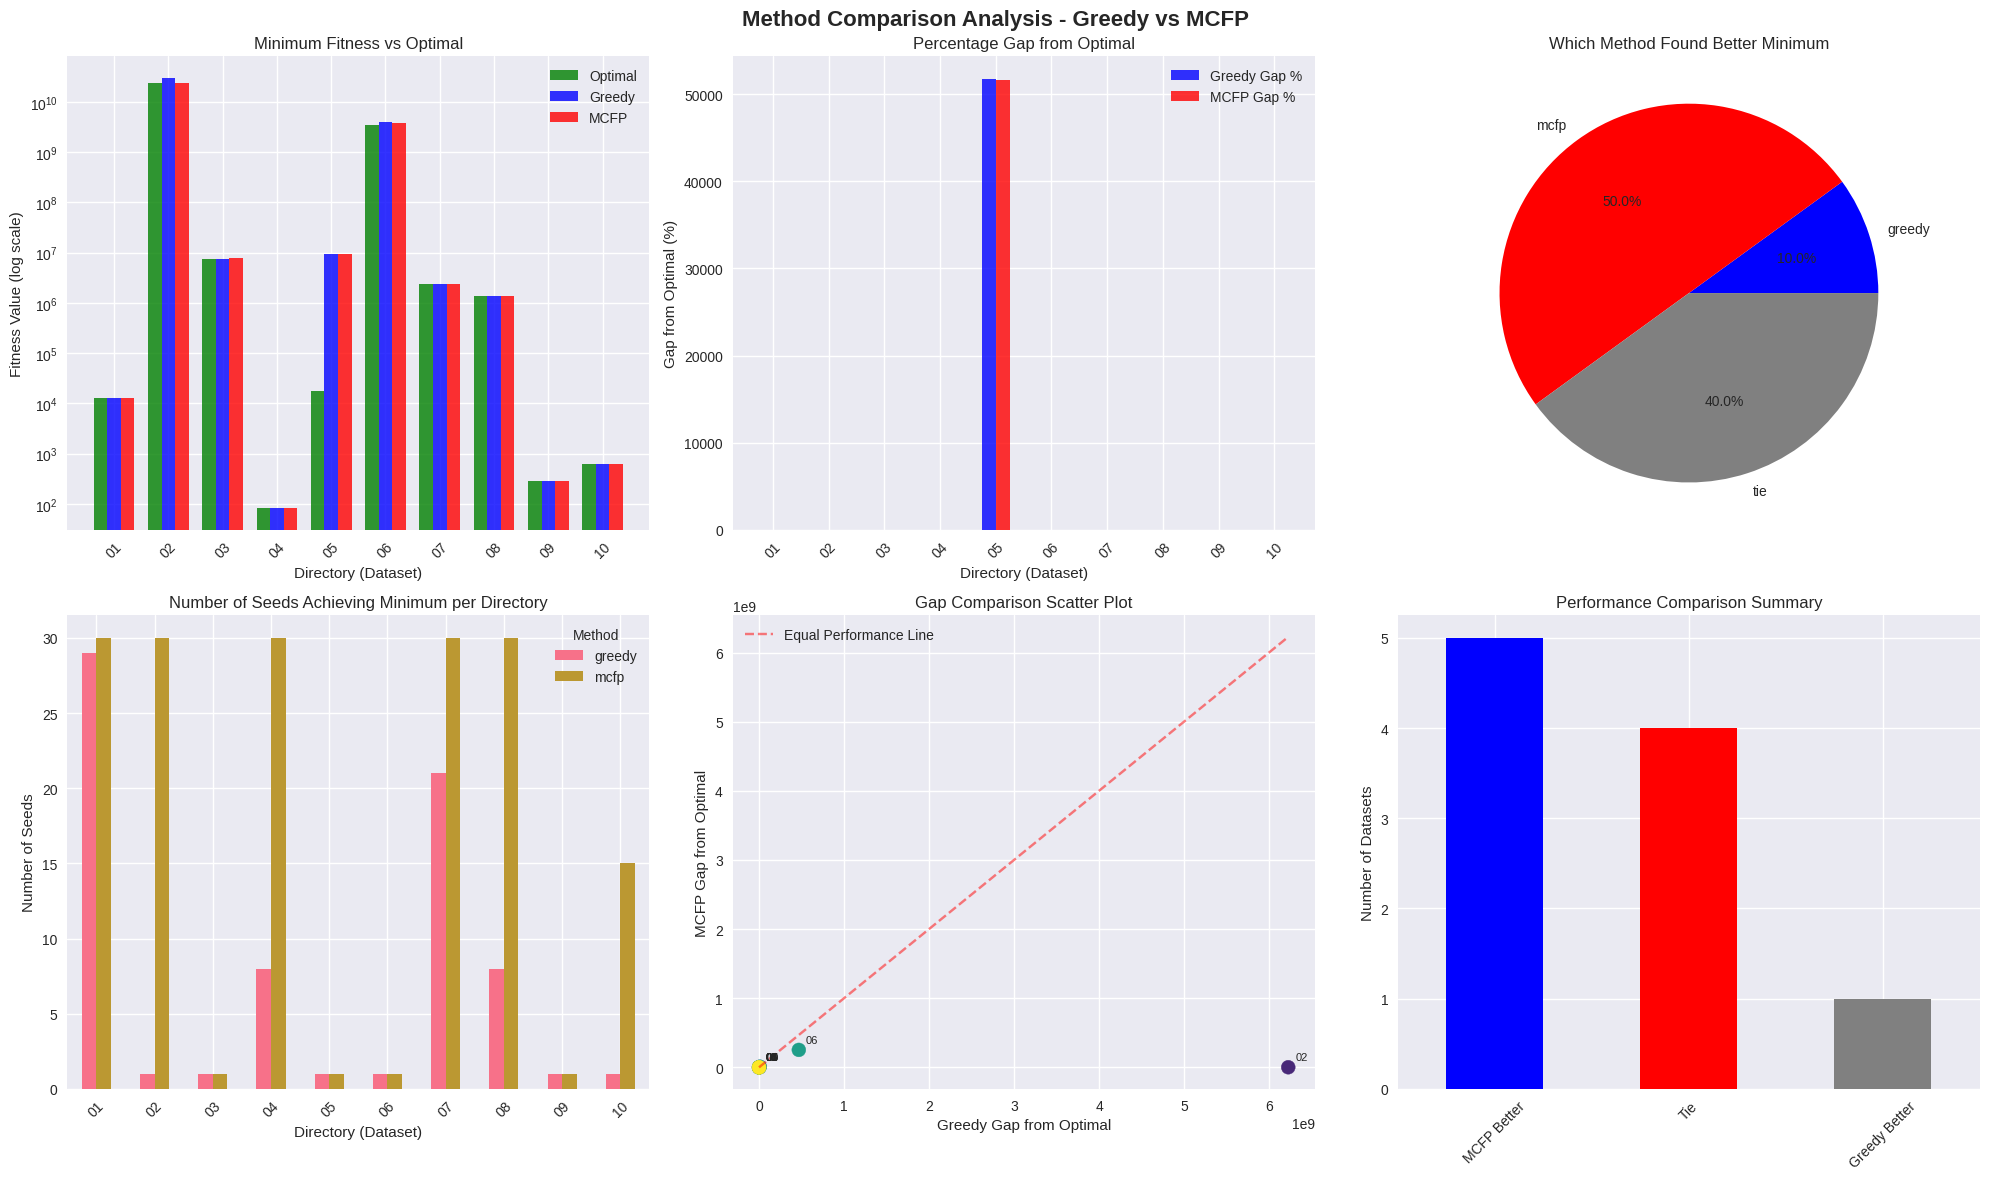


✓ Method comparison analysis saved to 'method_comparison_analysis.csv'
✓ Seed analysis results saved to 'seed_analysis_results.csv'


In [15]:
# Method Comparison Analysis
# Load optimal values from Real-world instances.md
optimal_values = {
    '01': 1.288e+04,
    '02': 2.371e+10,
    '03': 7.424e+06,
    '04': 8.127e+01,
    '05': 1.794e+04,
    '06': 3.498e+09,
    '07': 2.398e+06,
    '08': 1.364e+06,
    '09': 2.805e+02,
    '10': 6.056e+02
}

print("="*80)
print("METHOD COMPARISON ANALYSIS")
print("="*80)

# 1. Count how many times each method found the minimum
print("\n1. MINIMUM ACHIEVEMENT COUNT PER DIRECTORY")
print("-"*60)

min_count_results = []
better_method_count = {'greedy': 0, 'mcfp': 0, 'tie': 0}

for directory in sorted(min_fitness_df['directory'].unique()):
    dir_data = min_fitness_df[min_fitness_df['directory'] == directory]
    greedy_min = dir_data[dir_data['method'] == 'greedy']['min_fitness'].iloc[0]
    mcfp_min = dir_data[dir_data['method'] == 'mcfp']['min_fitness'].iloc[0]
    optimal = optimal_values[directory]
    
    # Determine which method found better minimum
    if greedy_min < mcfp_min:
        better_method = 'greedy'
        better_method_count['greedy'] += 1
    elif mcfp_min < greedy_min:
        better_method = 'mcfp'
        better_method_count['mcfp'] += 1
    else:
        better_method = 'tie'
        better_method_count['tie'] += 1
    
    # Calculate gaps from optimal
    greedy_gap = greedy_min - optimal
    mcfp_gap = mcfp_min - optimal
    greedy_gap_pct = (greedy_gap / optimal) * 100 if optimal != 0 else 0
    mcfp_gap_pct = (mcfp_gap / optimal) * 100 if optimal != 0 else 0
    
    min_count_results.append({
        'directory': directory,
        'optimal': optimal,
        'greedy_min': greedy_min,
        'mcfp_min': mcfp_min,
        'better_method': better_method,
        'greedy_gap': greedy_gap,
        'mcfp_gap': mcfp_gap,
        'greedy_gap_pct': greedy_gap_pct,
        'mcfp_gap_pct': mcfp_gap_pct
    })

min_comparison_df = pd.DataFrame(min_count_results)
print(min_comparison_df.round(4))

print(f"\n2. OVERALL MINIMUM ACHIEVEMENT SUMMARY")
print("-"*60)
print(f"Greedy found better minimum: {better_method_count['greedy']} times")
print(f"MCFP found better minimum: {better_method_count['mcfp']} times")
print(f"Both methods tied: {better_method_count['tie']} times")

# 3. Find which seeds achieved the minimum for each directory/method
print(f"\n3. SEEDS THAT ACHIEVED MINIMUM FITNESS")
print("-"*60)

seed_analysis = []
for directory in sorted(df['directory'].unique()):
    dir_data = df[df['directory'] == directory]
    
    for method in ['greedy', 'mcfp']:
        method_data = dir_data[dir_data['method'] == method]
        if not method_data.empty:
            min_fitness = method_data['fitness'].min()
            min_records = method_data[method_data['fitness'] == min_fitness]
            seeds = [record['scenario'] for _, record in min_records.iterrows()]
            
            seed_analysis.append({
                'directory': directory,
                'method': method,
                'min_fitness': min_fitness,
                'achieving_seeds': ', '.join(seeds),
                'seed_count': len(seeds)
            })

seed_df = pd.DataFrame(seed_analysis)
print(seed_df)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Method Comparison Analysis - Greedy vs MCFP', fontsize=16, fontweight='bold')

# 1. Minimum fitness comparison with optimal
ax1 = axes[0, 0]
x = range(len(min_comparison_df))
width = 0.25
ax1.bar([i-width for i in x], min_comparison_df['optimal'], width, label='Optimal', alpha=0.8, color='green')
ax1.bar([i for i in x], min_comparison_df['greedy_min'], width, label='Greedy', alpha=0.8, color='blue')
ax1.bar([i+width for i in x], min_comparison_df['mcfp_min'], width, label='MCFP', alpha=0.8, color='red')
ax1.set_xlabel('Directory (Dataset)')
ax1.set_ylabel('Fitness Value (log scale)')
ax1.set_yscale('log')
ax1.set_title('Minimum Fitness vs Optimal')
ax1.set_xticks(x)
ax1.set_xticklabels(min_comparison_df['directory'])
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# 2. Gap from optimal (percentage)
ax2 = axes[0, 1]
ax2.bar([i-width/2 for i in x], min_comparison_df['greedy_gap_pct'], width, label='Greedy Gap %', alpha=0.8, color='blue')
ax2.bar([i+width/2 for i in x], min_comparison_df['mcfp_gap_pct'], width, label='MCFP Gap %', alpha=0.8, color='red')
ax2.set_xlabel('Directory (Dataset)')
ax2.set_ylabel('Gap from Optimal (%)')
ax2.set_title('Percentage Gap from Optimal')
ax2.set_xticks(x)
ax2.set_xticklabels(min_comparison_df['directory'])
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# 3. Better method count
ax3 = axes[0, 2]
methods = list(better_method_count.keys())
counts = list(better_method_count.values())
colors = ['blue', 'red', 'gray']
ax3.pie(counts, labels=methods, autopct='%1.1f%%', colors=colors)
ax3.set_title('Which Method Found Better Minimum')

# 4. Seed count analysis
ax4 = axes[1, 0]
seed_pivot = seed_df.pivot(index='directory', columns='method', values='seed_count')
seed_pivot.plot(kind='bar', ax=ax4)
ax4.set_title('Number of Seeds Achieving Minimum per Directory')
ax4.set_xlabel('Directory (Dataset)')
ax4.set_ylabel('Number of Seeds')
ax4.legend(title='Method')
ax4.tick_params(axis='x', rotation=45)

# 5. Gap comparison (absolute values)
ax5 = axes[1, 1]
ax5.scatter(min_comparison_df['greedy_gap'], min_comparison_df['mcfp_gap'], 
           c=range(len(min_comparison_df)), cmap='viridis', s=100)
for i, directory in enumerate(min_comparison_df['directory']):
    ax5.annotate(directory, (min_comparison_df['greedy_gap'].iloc[i], min_comparison_df['mcfp_gap'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax5.plot([min(min_comparison_df['greedy_gap'].min(), min_comparison_df['mcfp_gap'].min()),
          max(min_comparison_df['greedy_gap'].max(), min_comparison_df['mcfp_gap'].max())],
         [min(min_comparison_df['greedy_gap'].min(), min_comparison_df['mcfp_gap'].min()),
          max(min_comparison_df['greedy_gap'].max(), min_comparison_df['mcfp_gap'].max())], 
         'r--', alpha=0.5, label='Equal Performance Line')
ax5.set_xlabel('Greedy Gap from Optimal')
ax5.set_ylabel('MCFP Gap from Optimal')
ax5.set_title('Gap Comparison Scatter Plot')
ax5.legend()

# 6. Method performance summary
ax6 = axes[1, 2]
performance_data = []
for directory in min_comparison_df['directory']:
    row = min_comparison_df[min_comparison_df['directory'] == directory].iloc[0]
    if row['greedy_gap_pct'] < row['mcfp_gap_pct']:
        performance_data.append('Greedy Better')
    elif row['mcfp_gap_pct'] < row['greedy_gap_pct']:
        performance_data.append('MCFP Better')
    else:
        performance_data.append('Tie')

performance_counts = pd.Series(performance_data).value_counts()
performance_counts.plot(kind='bar', ax=ax6, color=['blue', 'red', 'gray'])
ax6.set_title('Performance Comparison Summary')
ax6.set_ylabel('Number of Datasets')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Export comparison results
min_comparison_df.to_csv('method_comparison_analysis.csv', index=False)
seed_df.to_csv('seed_analysis_results.csv', index=False)
print("\n✓ Method comparison analysis saved to 'method_comparison_analysis.csv'")
print("✓ Seed analysis results saved to 'seed_analysis_results.csv'")

In [ ]:
# Export results to CSV for further analysis
print("\nExporting results...")

# Export minimum fitness data
min_fitness_df.to_csv('minimum_fitness_results.csv', index=False)
print("✓ Minimum fitness results saved to 'minimum_fitness_results.csv'")

# Export statistics
stats_df.to_csv('fitness_statistics.csv', index=False)
print("✓ Fitness statistics saved to 'fitness_statistics.csv'")

# Export complete dataset
df.to_csv('complete_fitness_data.csv', index=False)
print("✓ Complete dataset saved to 'complete_fitness_data.csv'")

print("\nReport generation complete!")